# Machine Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('insurance.csv')
df

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA (Exploratory Data Analysis)

In [4]:
print(f"The total number of rows in the DataFrame are: {df.shape[0]}")
print(f"The total number of cols in the DataFrame are: {df.shape[1]}")

The total number of rows in the DataFrame are: 1338
The total number of cols in the DataFrame are: 7


In [5]:
df.info() # Give information about DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe() # Describe the numerical cols

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Finding missing value in the DataFrame

In [19]:
df.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data Visualization

In [20]:
print(df.columns, "\n\n")
df.info()

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object') 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [21]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

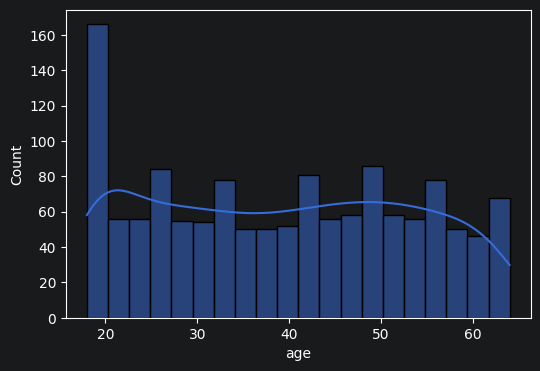

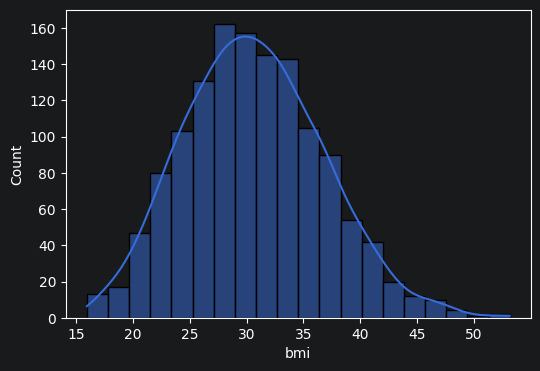

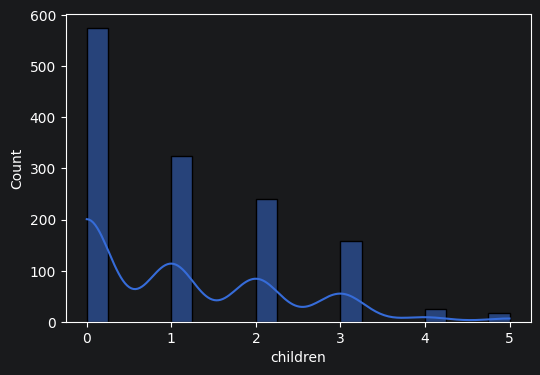

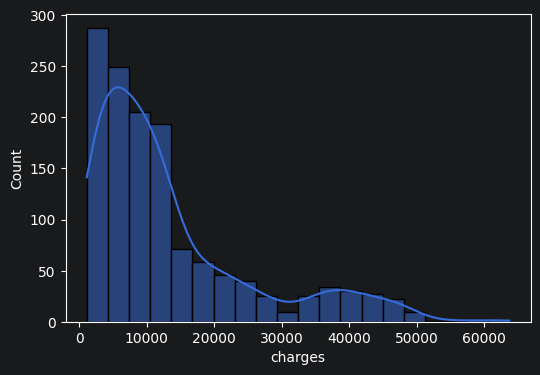

In [22]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sb.histplot(df[col], kde=True, bins=20)

### Count plots

<Axes: xlabel='children', ylabel='count'>

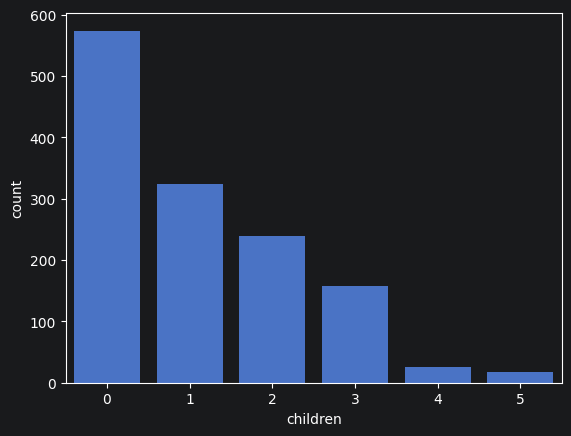

In [23]:
sb.countplot(x = df['children'])

<Axes: xlabel='gender', ylabel='count'>

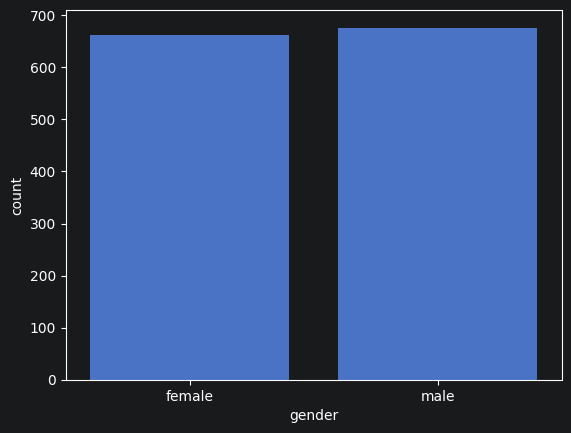

In [24]:
sb.countplot(x = df['gender'])

<Axes: xlabel='smoker', ylabel='count'>

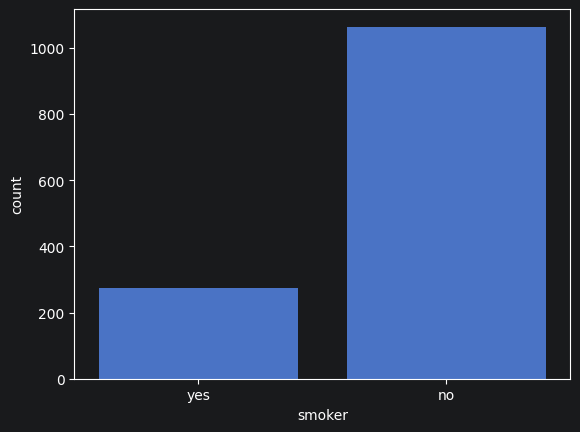

In [25]:
sb.countplot(x = df['smoker'])

<Axes: xlabel='region', ylabel='count'>

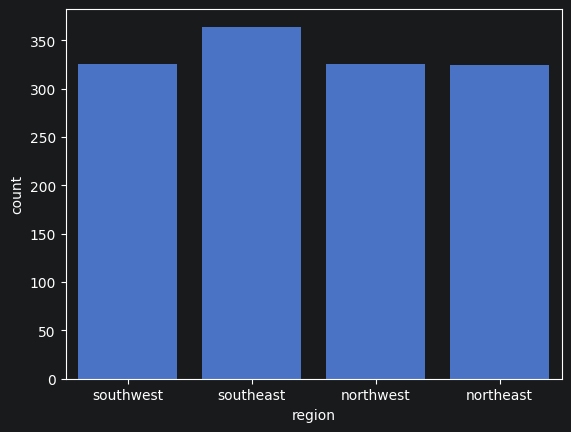

In [26]:
sb.countplot(x = df['region'])

### Box Plotting of Cols

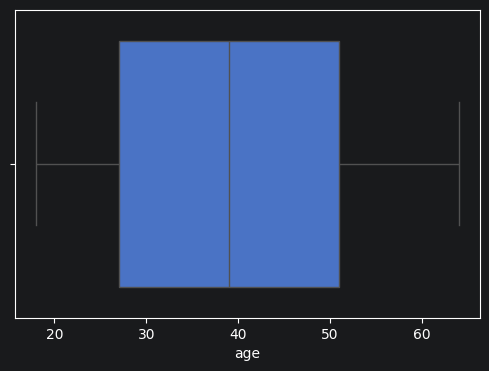

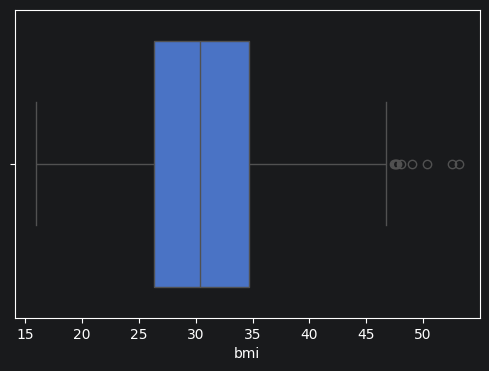

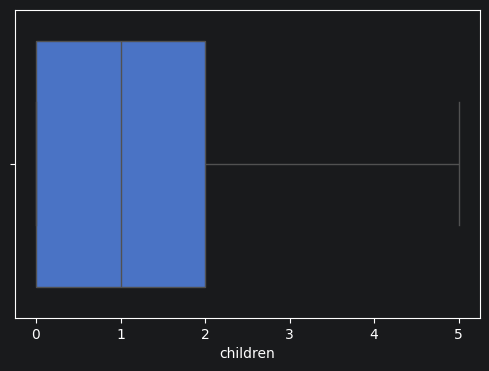

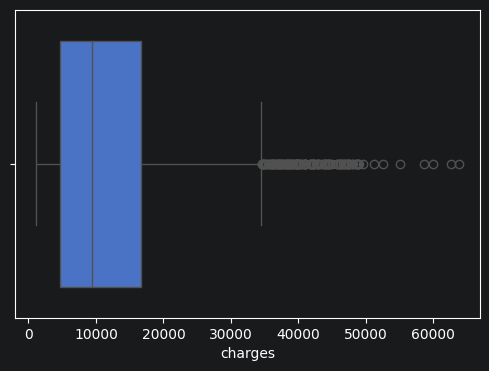

In [27]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sb.boxplot(x = df[col])

### Heat map correlation of cols

<Axes: >

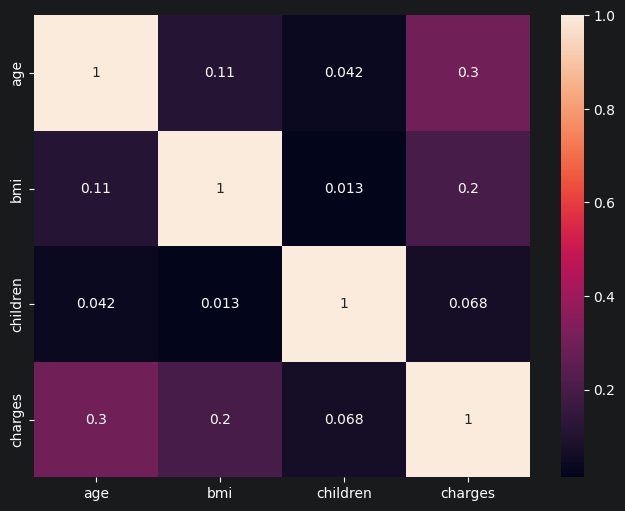

In [28]:
plt.figure(figsize=(8, 6))
sb.heatmap(df.corr(numeric_only=True), annot=True)

## Data Cleaning And Preprocessing

In [29]:
df_cleaned = df.copy()

In [30]:
df_cleaned.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [31]:
print(df_cleaned.shape)

(1338, 7)


In [32]:
df_cleaned.drop_duplicates(inplace=True)

In [33]:
print(df_cleaned.shape)

(1337, 7)


#### Find missing value in the DataFrame

In [34]:
df_cleaned.isnull().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Checking datatype of cols

In [35]:
df_cleaned.dtypes

age           int64
gender       object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [36]:
df_cleaned['gender'].value_counts()

male      675
female    662
Name: gender, dtype: int64

# Label Encoding

##### Mapping female as 1 and male as 0 for gender col

In [43]:
df_cleaned['gender'] = df_cleaned['gender'].map({
    "male": 0,
    "female": 1
})

In [44]:
df_cleaned.head(3)

,age,gender,bmi,children,smoker,region,charges
0,19,1,27.90,0,yes,southwest,16884.9240
1,18,0,33.77,1,no,southeast,1725.5523
2,28,0,33.00,3,no,southeast,4449.4620


In [45]:
df_cleaned['smoker'].value_counts()

no     1063
yes     274
Name: smoker, dtype: int64

In [46]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({
    "no" : 0,
    "yes": 1
})

In [47]:
df_cleaned.head()

,age,gender,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
